In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import shutil
import seaborn as sns
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.cm as cm
import re
import pingouin as pg
from scipy.stats import sem
from pathlib import Path

def find_project_root(start=None):
    p = Path(os.environ.get('MAZE_PROJECT_ROOT') or start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / '_DATA').is_dir() and (cand / 'Mazes').is_dir():
            return cand
    raise RuntimeError(
        f'Could not locate the project root (a folder holding _DATA/ and Mazes/) '
        f'from {p}. Set MAZE_PROJECT_ROOT to the repository root.')

project_path = str(find_project_root())
os.chdir(project_path)

home_path  = os.path.expanduser('~')
data_path  = os.path.join(project_path, '_DATA')
maze_dir   = os.path.join(project_path, 'Mazes')
figure_path = os.path.join(project_path, 'figures')
os.makedirs(figure_path, exist_ok=True)

print(project_path)
print(data_path)

/Users/minjaejo/Desktop/2025_Maze_Behavior
/Users/minjaejo/Desktop/2025_Maze_Behavior/_DATA


In [2]:
# Utils
def build_transition_prob(df):
    all_possible_states = [f'{row} {col}' for row in range(5) for col in range(5)]
    state_to_idx = {state: idx for idx, state in enumerate(all_possible_states)}
    
    M = np.zeros((len(state_to_idx), len(state_to_idx)))
    # assume : key doesn't matter. only looking at the cell location.
    # if it is in the same run, then it is a valid transition
    for index, row in df.iterrows():
        if index < len(df) - 1:
            if row['Key'] == 6 or pd.isnull(row['Location']):
                    continue
            current_state_idx = state_to_idx[row['Location']]
            if index + 1 < len(df):
                next_state_idx = state_to_idx[df.iloc[index+1]['Location']]
                M[current_state_idx, next_state_idx] += 1
                    
    row_sums = M.sum(axis=1)
    M = np.divide(M,row_sums[:, np.newaxis], out=np.zeros_like(M), where=row_sums[:, np.newaxis]!=0)
    return M

def jaccard_sim(m1, m2):
    return len(set(m1) & set(m2)) / len(set(m1) | set(m2))

def dice_coef(m1, m2):
    A, B = set(m1), set(m2)
    denom = len(A) + len(B)
    if denom == 0:
        return 0.0
    return 2 * len(A & B) / denom

def find_motif(M, goal):
    n = len(M)
    visited = []
    current_location = goal

    while True:
        visited.append(current_location)
        probabilities = M[:, current_location].copy()
        probabilities[current_location] = 0
        
        # find max prob
        prev_location = probabilities.argmax()
        
        # if there is a loop
        if prev_location in visited:
            break
        if probabilities[prev_location] == 0: # or no valid transition
            break
        
        current_location = prev_location

    return visited[::-1]

In [ ]:
cmap = ["#BF3131", "#E45A92", '#27548A', '#578FCA']  # EgoEgo, AlloEgo, EgoAllo, AlloAllo
exclude_subs = []

file_types = ['EgoEgo', 'AlloEgo', 'AlloAllo', 'EgoAllo']  # all 4 needed for the split plot below
stats_list = []
collapsed_list = []
sim_list = []

for i, file_type in enumerate(file_types):

    subject_dirs = [os.path.join(data_path, d) for d in os.listdir(data_path)
                    if os.path.isdir(os.path.join(data_path, d)) and d.startswith('Sub-')]
    subject_dirs = [d for d in subject_dirs if not any(sub in d for sub in exclude_subs)]


    frames = []
    for dir in subject_dirs:
        fp = os.path.join(dir, f"{os.path.basename(dir).lower()}_{file_type}.csv")
        if os.path.exists(fp):
            df = pd.read_csv(fp)
            subject_id = int(os.path.basename(dir).split('-')[1])
            df['subject_id'] = subject_id
            frames.append(df)

    if not frames:
        print(f"[!] No data found for {file_type}")
        continue
    
    all_data = pd.concat(frames, ignore_index=True).sort_values(by=['subject_id', 'Run']).reset_index(drop=True)
    # calculate motifs for each subject and each phaseview, mazetype
    grouped = all_data.groupby(['subject_id', 'PhaseView', 'MazeType'])
    motif_results = []
    sim_results = []

    for (subject_id, condition, maze), group in grouped:
        # make group to dataframe
        group = group.reset_index(drop=True)
        M = build_transition_prob(group)
        motifs = {i: find_motif(M, i) for i in range(25)}
        
        motif_results.append({
            'subject_id': subject_id,
            'PhaseView': condition,
            'MazeType': maze,
            'motifs': motifs
        })

    motif_df = pd.DataFrame(motif_results)
    # written per condition: the motif-similarity cell below reads these back
    motif_df.to_csv(os.path.join(project_path, f'motif_results_{file_type}.csv'), index=False)

    # calculate similarity between different phaseview, same mazetype, same subject
    sims = []
    for sub_id, sub_group in motif_df.groupby(['subject_id', 'MazeType']):
        if len(sub_group)!=2:
            print('no data for both phase view @ ', sub_id)
            continue
        
        maze = sub_group.iloc[0]['MazeType']
        sims_per_sub = []  # FIX: must be reset for every (subject, maze);
                           # previously it accumulated across subjects, so each
                           # subject's value was a running mean over all prior subjects
                           # (group means roughly OK, between-subject variance destroyed)
        
        for i in range(25):
            for j in range(25):
                if i==j:
                    sims_per_sub.append(jaccard_sim(sub_group.iloc[0]['motifs'][i], sub_group.iloc[1]['motifs'][i]))
                    
        sim = np.round(np.mean(sims_per_sub),5) if sims_per_sub else 0
        
        # print(sim)
        
        sims.append({
            'subject_id': sub_id[0],
            'MazeType': maze,
            'similarity': sim
        })
        
    # calculate mean of similarity between mazetypes for every subject
    sim_df = pd.DataFrame(sims)
    sim_df = sim_df.groupby(['subject_id']).mean('similarity').reset_index().drop(columns=['MazeType'])
    # add column for file_type
    sim_df['FileType'] = file_type
    sim_list.append(sim_df)

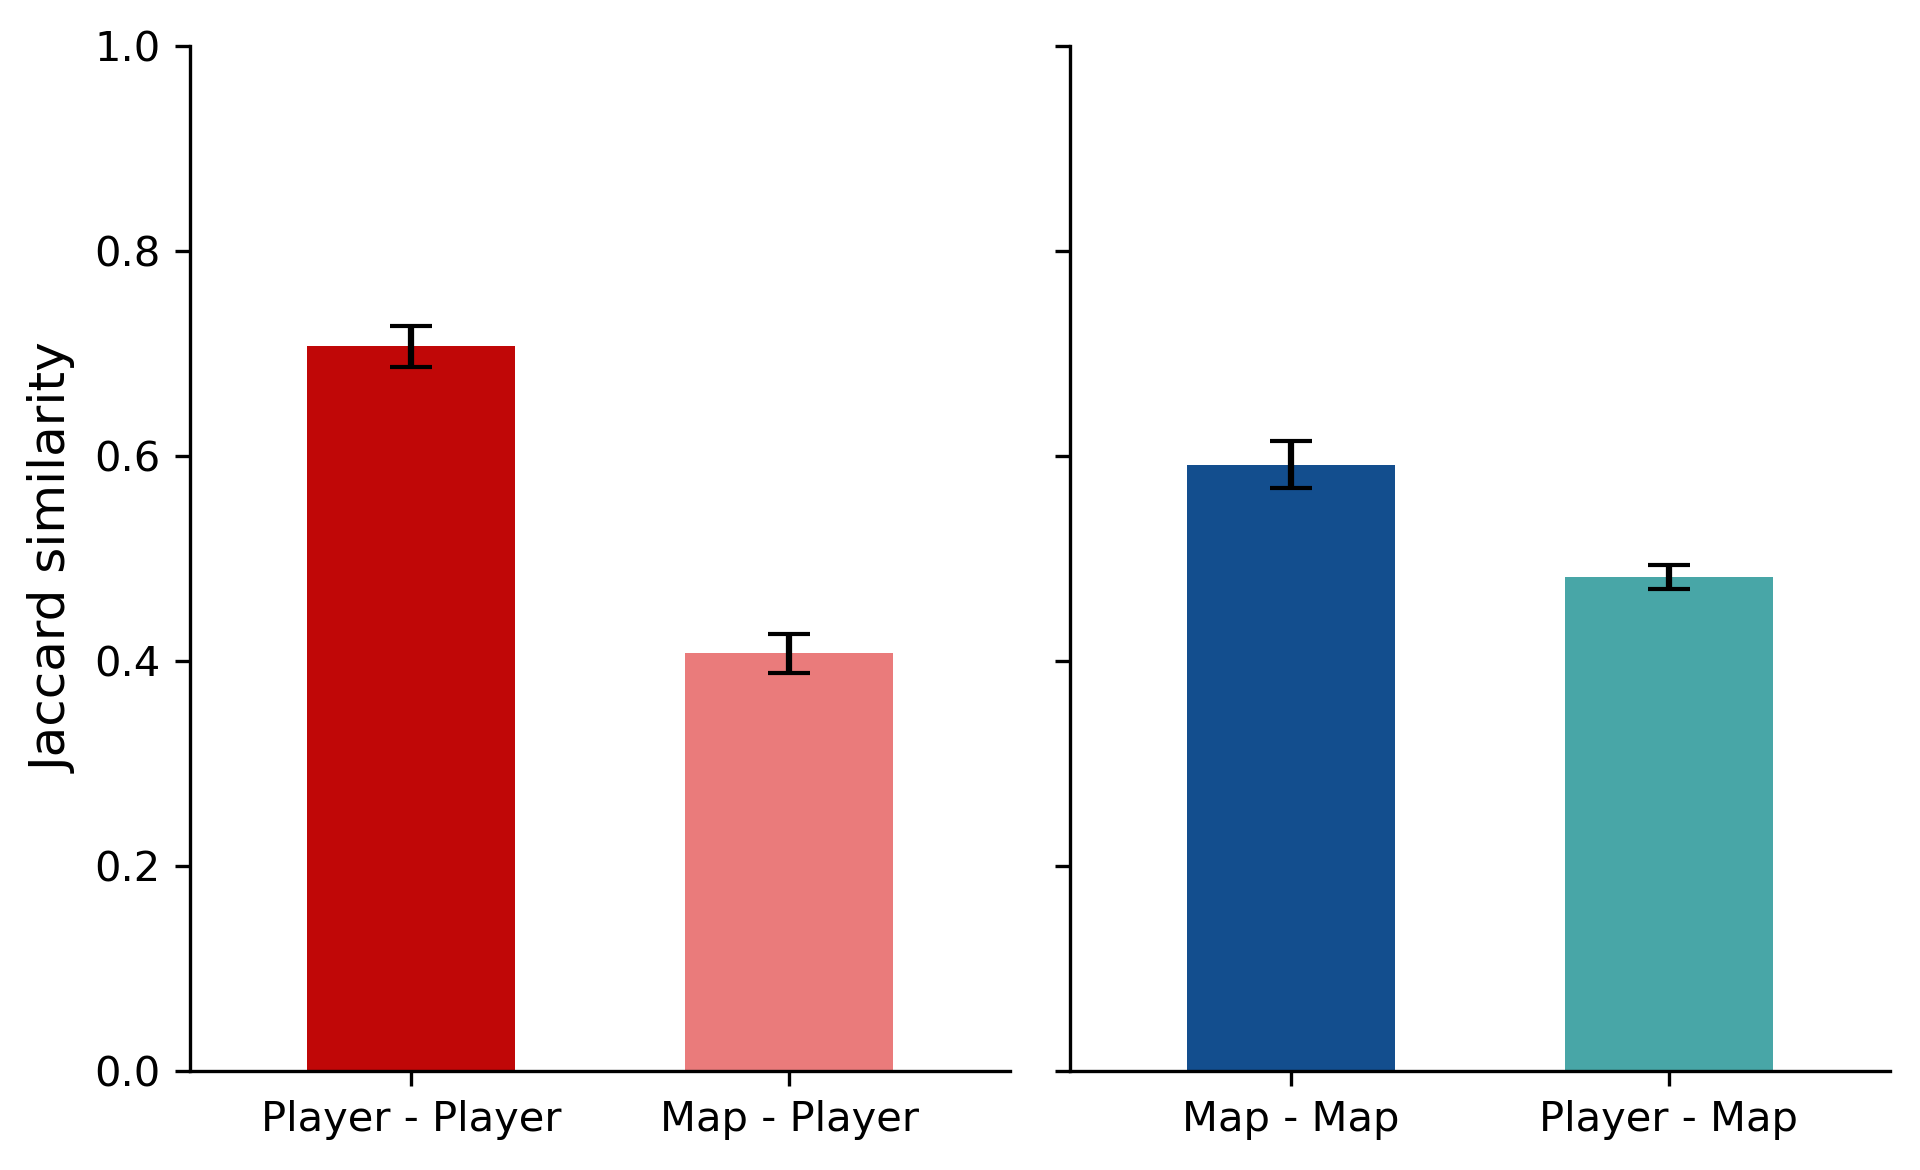

In [4]:
# turn sim_list into a single dataframe
final_sim_df = pd.concat(sim_list, ignore_index=True)
#final_sim_df.to_csv(os.path.join(project_path, 'motif_similarity_results.csv'), index=False)
stats= (
    final_sim_df.groupby('FileType')['similarity']
    .agg(['mean', sem])
    .reset_index()
)
stats['FileType'] = pd.Categorical(stats['FileType'], categories=file_types, ordered=True)
stats = stats.sort_values('FileType')

group1 = stats[stats['FileType'].isin(['EgoEgo', 'AlloEgo'])]  # FPV→FPV, TPV→FPV
group2 = stats[stats['FileType'].isin(['AlloAllo', 'EgoAllo'])]  # TPV→TPV, FPV→TPV

colors = ["#C00707", "#EA7B7B", '#134E8E', '#48A6A7']  # EgoEgo, AlloEgo, EgoAllo, AlloAllo
cmap1 = colors[:2]
cmap2 = colors[2:]

fig, axes = plt.subplots(1, 2, figsize=(6.5, 4), dpi=300, sharey=True)
plt.subplots_adjust(wspace=0.15) 

# --- 왼쪽: FPV에서 테스트된 조건 ---
axes[0].bar(['Player - Player', 'Map - Player'], group1['mean'], 
            yerr=group1['sem'], capsize=5, 
            color=cmap1,
            width=0.55)

axes[0].set_ylabel("Jaccard similarity", fontsize=12)
axes[0].set_ylim(0, 1.0)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# --- 오른쪽: TPV에서 테스트된 조건 ---
axes[1].bar(['Map - Map', 'Player - Map'], group2['mean'], 
            yerr=group2['sem'], capsize=5, 
            
            color=cmap2,
            width=0.55)

axes[1].set_ylim(0, 1.0)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

for ax in axes:
    ax.tick_params(axis='y', labelsize=10)
    ax.margins(x=0.2)
plt.tight_layout()
plt.savefig(os.path.join(project_path, './figures/BEH_03_motif_similarity_split.png'))
# plt.show()

### Motif similarity — statistics

Design: two independent subject groups (n = 20 each). Within each group, training view
(FPV vs TPV) is **within-subject** and both conditions are compared against the *same*
test phase; test view (FPV vs TPV) is **between-subject**.

| Group | Congruent | Incongruent |
|---|---|---|
| FPV test (PhaseView 2) | EgoEgo (0→2) | AlloEgo (1→2) |
| TPV test (PhaseView 3) | AlloAllo (1→3) | EgoAllo (0→3) |

Similarity is recomputed here from `motif_results_{FileType}.csv` (written by the cell
under "Motif length"), so these cells are independent of the raw-data loop above.

In [5]:
# --- Motif similarity per subject (recomputed from motif_results_{FileType}.csv) ---
import ast

file_types = ['EgoEgo', 'AlloEgo', 'AlloAllo', 'EgoAllo']

rows = []
for ft in file_types:
    d = pd.read_csv(os.path.join(project_path, f'motif_results_{ft}.csv'))
    d['motifs'] = d['motifs'].apply(ast.literal_eval)
    for (sub, maze), g in d.groupby(['subject_id', 'MazeType']):
        if len(g) != 2:
            print(f'[!] {ft} sub {sub} maze {maze}: {len(g)} PhaseView rows -- skipped')
            continue
        g = g.sort_values('PhaseView')
        m_a, m_b = g.iloc[0]['motifs'], g.iloc[1]['motifs']
        # Jaccard per goal state, averaged over the 25 goals
        per_goal = [jaccard_sim(m_a[i], m_b[i]) for i in range(25)]
        rows.append({'FileType': ft, 'subject_id': sub, 'MazeType': maze,
                     'similarity': float(np.mean(per_goal))})

per_maze_sim = pd.DataFrame(rows)
# average the 4 mazes within subject -> one value per subject per condition
final_sim_df = (per_maze_sim.groupby(['FileType', 'subject_id'], as_index=False)['similarity'].mean())

# design factors: TrainView is within-subject, TestView is between-subject
final_sim_df['TestView']  = final_sim_df['FileType'].map(
    {'EgoEgo': 'FPV', 'AlloEgo': 'FPV', 'AlloAllo': 'TPV', 'EgoAllo': 'TPV'})
final_sim_df['TrainView'] = final_sim_df['FileType'].map(
    {'EgoEgo': 'FPV', 'EgoAllo': 'FPV', 'AlloEgo': 'TPV', 'AlloAllo': 'TPV'})
final_sim_df['Congruent'] = np.where(
    final_sim_df['TrainView'] == final_sim_df['TestView'], 'congruent', 'incongruent')

final_sim_df.to_csv(os.path.join(project_path, 'BEH_03_motif_similarity.csv'), index=False)
print(final_sim_df.groupby(['TestView', 'FileType']).size())

TestView  FileType
FPV       AlloEgo     20
          EgoEgo      20
TPV       AlloAllo    20
          EgoAllo     20
dtype: int64


In [6]:
# --- Descriptives ---
sim_stats = (
    final_sim_df.groupby('FileType')['similarity']
    .agg(n='count', mean='mean', sd='std',
         sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)), min='min', max='max')
    .reindex(file_types)
    .round(4)
)
print(sim_stats)

           n    mean      sd     sem     min     max
FileType                                            
EgoEgo    20  0.7065  0.0897  0.0201  0.5827  0.9067
AlloEgo   20  0.4071  0.0849  0.0190  0.2632  0.5560
AlloAllo  20  0.5913  0.1022  0.0229  0.4177  0.7975
EgoAllo   20  0.4814  0.0527  0.0118  0.3973  0.5972


In [7]:
# --- Within-group paired comparisons: congruent vs incongruent training view ---
from scipy.stats import shapiro
from statsmodels.stats.multitest import multipletests

wide = final_sim_df.pivot(index='subject_id', columns='FileType', values='similarity')

def paired_test(ft_congruent, ft_incongruent, label):
    w = wide[[ft_congruent, ft_incongruent]].dropna()
    a, b = w[ft_congruent].values, w[ft_incongruent].values
    diff = a - b
    sh = shapiro(diff)
    tt = pg.ttest(a, b, paired=True)
    wc = pg.wilcoxon(a, b)
    print(f'--- {label}: {ft_congruent} vs {ft_incongruent} (n={len(a)}) ---')
    print(f'  M({ft_congruent})={a.mean():.4f} (SD {a.std(ddof=1):.4f}) | '
          f'M({ft_incongruent})={b.mean():.4f} (SD {b.std(ddof=1):.4f}) | diff={diff.mean():+.4f}')
    print(f'  Shapiro-Wilk on differences: W={sh.statistic:.3f}, p={sh.pvalue:.4f}')
    print(f"  Paired t: t({int(tt['dof'].iloc[0])})={tt['T'].iloc[0]:.3f}, p={tt['p-val'].iloc[0]:.3e}, "
          f"g={tt['cohen-d'].iloc[0]:.3f}, 95%CI={tt['CI95%'].iloc[0]}, BF10={tt['BF10'].iloc[0]}")
    print(f"  Wilcoxon: W={wc['W-val'].iloc[0]:.1f}, p={wc['p-val'].iloc[0]:.3e}, RBC={wc['RBC'].iloc[0]:.3f}\n")
    return tt['p-val'].iloc[0]

p_fpv = paired_test('EgoEgo',   'AlloEgo', 'FPV-test group')
p_tpv = paired_test('AlloAllo', 'EgoAllo', 'TPV-test group')

_, p_holm, _, _ = multipletests([p_fpv, p_tpv], method='holm')
print(f'Holm-corrected: FPV-test p={p_holm[0]:.3e}, TPV-test p={p_holm[1]:.3e}')

--- FPV-test group: EgoEgo vs AlloEgo (n=20) ---
  M(EgoEgo)=0.7065 (SD 0.0897) | M(AlloEgo)=0.4071 (SD 0.0849) | diff=+0.2995
  Shapiro-Wilk on differences: W=0.977, p=0.8824
  Paired t: t(19)=11.024, p=1.071e-09, g=3.428, 95%CI=[0.24 0.36], BF10=1.002e+07
  Wilcoxon: W=0.0, p=1.907e-06, RBC=1.000

--- TPV-test group: AlloAllo vs EgoAllo (n=20) ---
  M(AlloAllo)=0.5913 (SD 0.1022) | M(EgoAllo)=0.4814 (SD 0.0527) | diff=+0.1099
  Shapiro-Wilk on differences: W=0.955, p=0.4486
  Paired t: t(19)=3.984, p=7.939e-04, g=1.352, 95%CI=[0.05 0.17], BF10=44.715
  Wilcoxon: W=22.0, p=1.017e-03, RBC=0.790

Holm-corrected: FPV-test p=2.142e-09, TPV-test p=7.939e-04


In [8]:
# --- 2x2 mixed ANOVA ---
print('TrainView (within) x TestView (between)')
print(pg.mixed_anova(data=final_sim_df, dv='similarity', within='TrainView',
                     subject='subject_id', between='TestView').round(4), '\n')

print('Congruency (within) x TestView (between)')
print(pg.mixed_anova(data=final_sim_df, dv='similarity', within='Congruent',
                     subject='subject_id', between='TestView').round(4), '\n')

# --- Between-group follow-ups (independent samples) ---
print('Between-group comparisons')
for a, b in [('EgoEgo', 'AlloAllo'), ('AlloEgo', 'EgoAllo')]:
    x = final_sim_df.loc[final_sim_df.FileType == a, 'similarity'].values
    y = final_sim_df.loc[final_sim_df.FileType == b, 'similarity'].values
    tt = pg.ttest(x, y, paired=False, correction='auto')
    print(f'  {a} (M={x.mean():.4f}) vs {b} (M={y.mean():.4f}): '
          f"t({tt['dof'].iloc[0]:.1f})={tt['T'].iloc[0]:.3f}, "
          f"p={tt['p-val'].iloc[0]:.4f}, d={tt['cohen-d'].iloc[0]:.3f}")

TrainView (within) x TestView (between)
        Source      SS  DF1  DF2      MS         F   p-unc     np2  eps
0     TestView  0.0084    1   38  0.0084    1.2413  0.2722  0.0316  NaN
1    TrainView  0.1796    1   38  0.1796   23.9598  0.0000  0.3867  1.0
2  Interaction  0.8381    1   38  0.8381  111.7952  0.0000  0.7463  NaN 

Congruency (within) x TestView (between)
        Source      SS  DF1  DF2      MS         F   p-unc     np2  eps
0     TestView  0.0084    1   38  0.0084    1.2413  0.2722  0.0316  NaN
1    Congruent  0.8381    1   38  0.8381  111.7952  0.0000  0.7463  1.0
2  Interaction  0.1796    1   38  0.1796   23.9598  0.0000  0.3867  NaN 

Between-group comparisons
  EgoEgo (M=0.7065) vs AlloAllo (M=0.5913): t(38.0)=3.789, p=0.0005, d=1.198
  AlloEgo (M=0.4071) vs EgoAllo (M=0.4814): t(38.0)=-3.324, p=0.0020, d=1.051


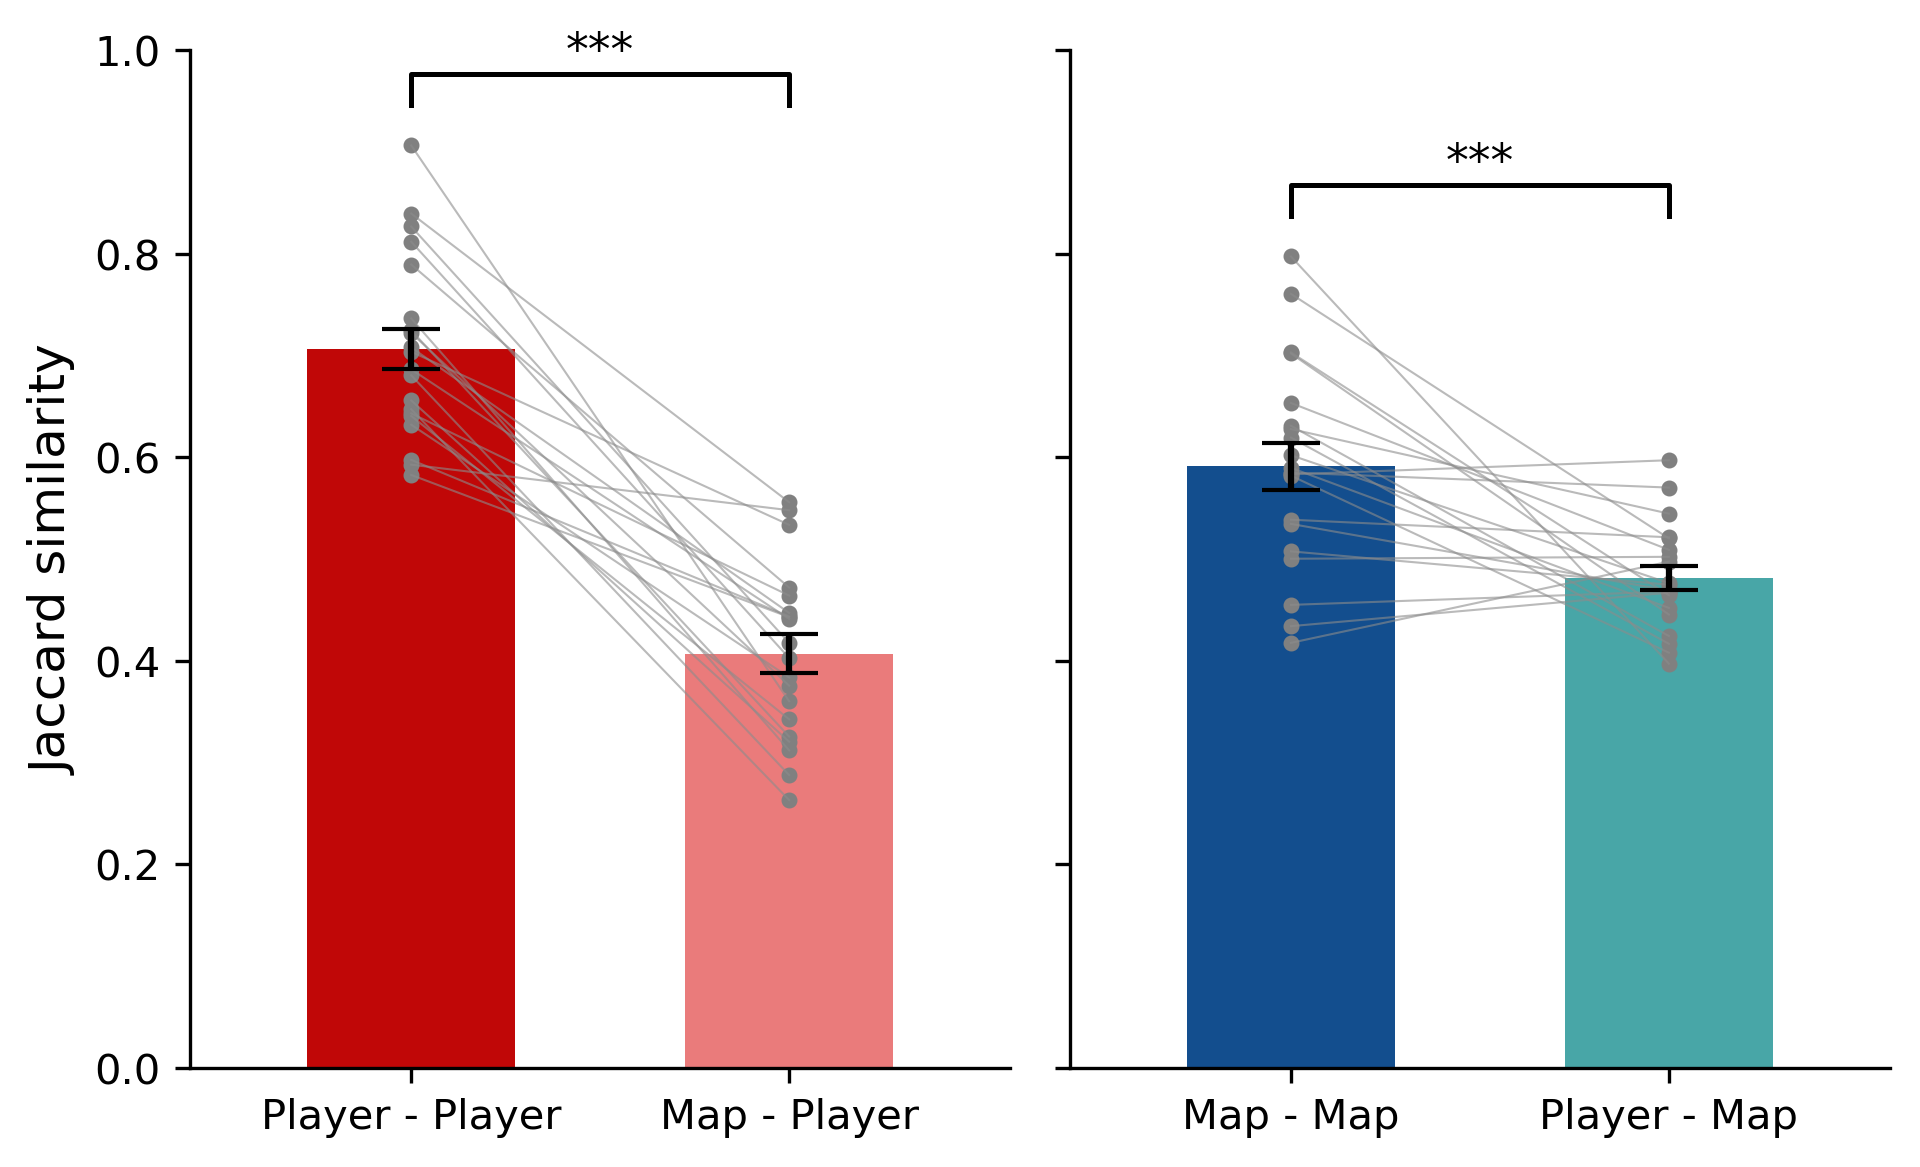

In [9]:
# --- Figure: motif similarity, corrected SEM + significance markers ---
def p_stars(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'

def sig_bracket(ax, x1, x2, y, p, h=0.03, lw=1.2):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c='k', clip_on=False)
    ax.text((x1 + x2) / 2, y + h, p_stars(p), ha='center', va='bottom',
            fontsize=11 if p < .05 else 9)

panels = [
    {'ax': 0, 'fts': ['EgoEgo', 'AlloEgo'],   'labels': ['Player - Player', 'Map - Player'],
     'colors': ["#C00707", "#EA7B7B"], 'p': p_holm[0]},
    {'ax': 1, 'fts': ['AlloAllo', 'EgoAllo'], 'labels': ['Map - Map', 'Player - Map'],
     'colors': ['#134E8E', '#48A6A7'], 'p': p_holm[1]},
]

fig, axes = plt.subplots(1, 2, figsize=(6.5, 4), dpi=300, sharey=True)
plt.subplots_adjust(wspace=0.15)

for pan in panels:
    ax = axes[pan['ax']]
    means = [sim_stats.loc[ft, 'mean'] for ft in pan['fts']]
    sems  = [sim_stats.loc[ft, 'sem']  for ft in pan['fts']]

    ax.bar(pan['labels'], means, yerr=sems, capsize=7,
       color=pan['colors'], width=0.55, zorder=2,
       error_kw={'zorder': 5})

    # paired subject-level data
    w = wide[pan['fts']].dropna()
    for _, r in w.iterrows():
        ax.plot([0, 1], r.values, color='0.55', lw=0.5, alpha=0.6, zorder=3)
    ax.scatter(np.zeros(len(w)), w[pan['fts'][0]], s=8, color='0.5', zorder=2)
    ax.scatter(np.ones(len(w)),  w[pan['fts'][1]], s=8, color='0.5', zorder=2)

    sig_bracket(ax, 0, 1, max(w.values.max(), max(means) + max(sems)) + 0.04, pan['p'])

    ax.set_ylim(0, 1.0)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)
    ax.margins(x=0.2)

axes[0].set_ylabel("Jaccard similarity", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(project_path, './figures/BEH_03_motif_similarity_split_corrected.svg'),
            dpi=300, bbox_inches='tight')
plt.show()